In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplcyberpunk as cp

In [10]:
df = pd.read_csv('D:\\Machine_learning_pratice_files_🔗\\model_evaluate_🌵\\sunflowers_2🌿\\dataset\\Teen_Mental_Health_Dataset.csv')

In [11]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [14]:
df['age'].min()

np.int64(13)

In [16]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [12]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [4]:
x = df.drop(columns='academic_performance')
y = df['academic_performance']

In [39]:
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import Ridge,Lasso,ElasticNet,SGDRegressor

from feature_engine.pipeline import Pipeline
from feature_engine.wrappers import SklearnTransformerWrapper


In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 shuffle=True,random_state=42,
                                                 test_size=0.2)

In [31]:
processing_pipe = Pipeline([
    ('Ohe', SklearnTransformerWrapper(
        transformer=OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False),
        variables=['gender', 'platform_usage']
    )),

    ('Ord', SklearnTransformerWrapper(
        transformer=OrdinalEncoder(categories=[['low', 'medium', 'high']]),
        variables=['social_interaction_level']
    )),

    ('scale', SklearnTransformerWrapper(
        transformer=StandardScaler()
    )),
    # ('model',LinearRegression())
])

In [8]:
scores = []
cross_vals = cross_val_score(
    processing_pipe,
    x_train,y_train,
    scoring='r2',
    n_jobs=-1,
    cv=5
)
scores.append(cross_vals)
print(scores)
print(np.mean(scores))

[array([ 0.00382544, -0.01638678, -0.05605786, -0.07120047,  0.0008075 ])]
-0.027802431831300913


In [27]:
train_size,train_score,val_score = learning_curve(processing_pipe,
                                                  x_train,
                                                  y_train,
                                                  train_sizes=np.linspace(0.1,1,50),
                                                  scoring='r2',
                                                  random_state=42,
                                                  n_jobs=-1,
                                                  verbose=True)

[learning_curve] Training set sizes: [ 76  90 105 119 133 147 161 175 189 203 217 231 246 260 274 288 302 316
 330 344 358 373 387 401 415 429 443 457 471 485 499 514 528 542 556 570
 584 598 612 626 641 655 669 683 697 711 725 739 753 768]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:    8.4s finished


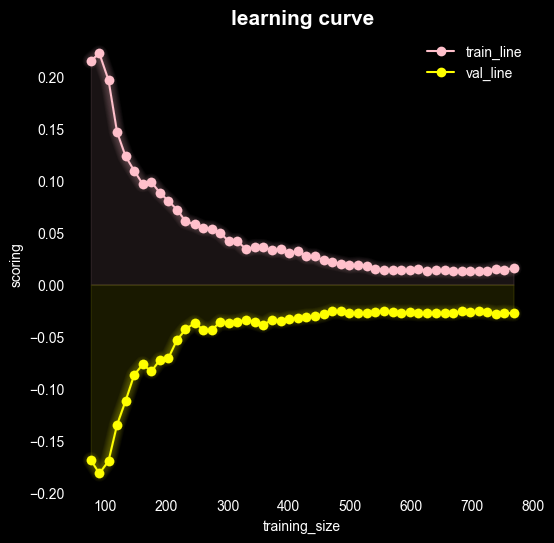

In [29]:
fig,ax = plt.subplots(figsize=(6,6))
plt.style.use('dark_background')

ax.plot(train_size,train_score.mean(axis=1),color='pink',label='train_line',marker='o')
ax.plot(train_size,val_score.mean(axis=1),color='yellow',label='val_line',marker='o')
ax.set_title('learning curve',fontdict={'fontweight':'bold','fontsize':15})
ax.set_xlabel('training_size')
ax.set_ylabel('scoring')
ax.legend()
ax.grid(False)
cp.add_glow_effects()
plt.show()


In [11]:
processing_pipe.fit(x_train,y_train)

,steps,"[('Ohe', ...), ('Ord', ...), ...]"
,memory,None
,verbose,False
,transformer,OneHotEncoder..._output=False)
,variables,"['gender', 'platform_usage']"
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with 

In [12]:
y_pred = processing_pipe.predict(x_test)

In [13]:
print(f'mean_squred_error is {mean_squared_error(y_test,y_pred)}')
print(f'mean_absolute_error is {mean_absolute_error(y_test,y_pred)}')
print(f'r2 score is {r2_score(y_test,y_pred)}')

mean_squred_error is 0.33477037188017544
mean_absolute_error is 0.4921478396682815
r2 score is -0.02296490193915557


In [14]:
residuals = y_test - y_pred

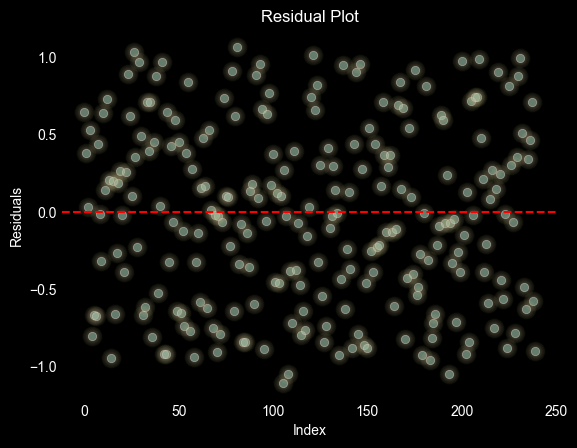

In [15]:
plt.style.use('dark_background')
sns.scatterplot(x=range(len(residuals)), y=residuals,alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(False)

cp.make_scatter_glow()
plt.show()

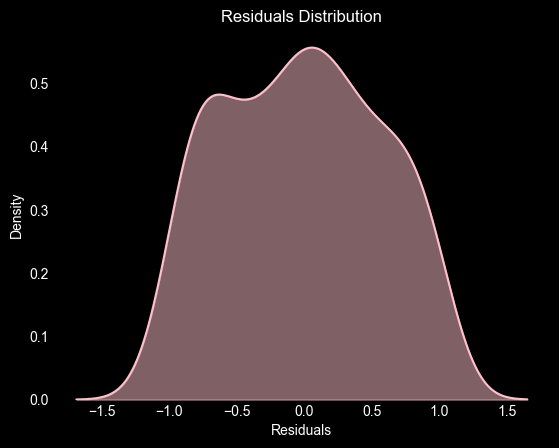

In [45]:
sns.kdeplot(residuals,color='pink')
plt.xlabel("Residuals")
plt.title("Residuals Distribution")
plt.grid(False)
cp.add_underglow(alpha_underglow=0.5)
plt.show()

In [25]:
training_score = processing_pipe.score(x_train,y_train)
test_score = processing_pipe.score(x_test,y_test)
print(f'{training_score= }')
print('🐳'*10)
print(f'{test_score= }')


training_score= 0.011750424186735775
🐳🐳🐳🐳🐳🐳🐳🐳🐳🐳
test_score= -0.02296490193915557


In [40]:
models = {
    'Ridge':Ridge(max_iter=100),
    'Lasso': Lasso(max_iter=100),
    'ElasticNet': ElasticNet(max_iter=100),
    'SGD': SGDRegressor(penalty='l2'),
    'tree': RandomForestRegressor(max_depth=5,max_features=7,max_samples=7)
}
scores = {}

for name,model in models.items():
    testing_pipe =Pipeline(steps = [
        ('process',processing_pipe),
        ('model',model)
    ])

    score = cross_val_score(testing_pipe,x_train,
                            y_train,scoring='r2',cv=5,
                            n_jobs=-1)
    scores[name] = score

print(scores)

{'Ridge': array([ 0.0038295 , -0.0163475 , -0.05596837, -0.07105942,  0.00081077]), 'Lasso': array([-0.002058  , -0.00086733, -0.00670462, -0.01419785, -0.00045936]), 'ElasticNet': array([-0.002058  , -0.00086733, -0.00670462, -0.01419785, -0.00045936]), 'SGD': array([ 0.00586749, -0.02124941, -0.06371335, -0.07140079, -0.00489419]), 'tree': array([-0.0382494 ,  0.00475679, -0.02554171, -0.03800525,  0.01167031])}


In [41]:
for key,values in scores.items():
    print(key,np.mean(values))

Ridge -0.027747003925883806
Lasso -0.004857429909995626
ElasticNet -0.004857429909995626
SGD -0.03107804863653867
tree -0.017073851303103592
